In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import warnings
from pathlib import Path
warnings.filterwarnings("ignore")

_HERE = Path.cwd()
_ROOT = _HERE.parent if _HERE.name == "EDA" else _HERE
_EDA  = _ROOT / "EDA"
for _p in (str(_ROOT), str(_EDA)):
    if _p not in sys.path:
        sys.path.insert(0, _p)

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns

from config import DATA_DIR, PATHS, PARAMS, EDA_BIAS_BATCH_DIR, EDA_BIAS_METRICS, EDA_COMBINED_METRICS
from analysis.plot_batch import (
    plot_batch_metric_violins,
    analyze_batch_statistics,
    check_batch_classification_power,
    check_discrete_covariate_batch_effects,
    plot_covariate_auc_heatmap,
    plot_covariate_auc_violins,
)
from viz_style import apply_style
apply_style()

In [3]:
adata = sc.read_h5ad(PATHS["merged_qc"])
adata = adata[adata.obs["QC_Passed"] == True]

combined_metrics = EDA_COMBINED_METRICS

### Bias ~ Batch Relationship

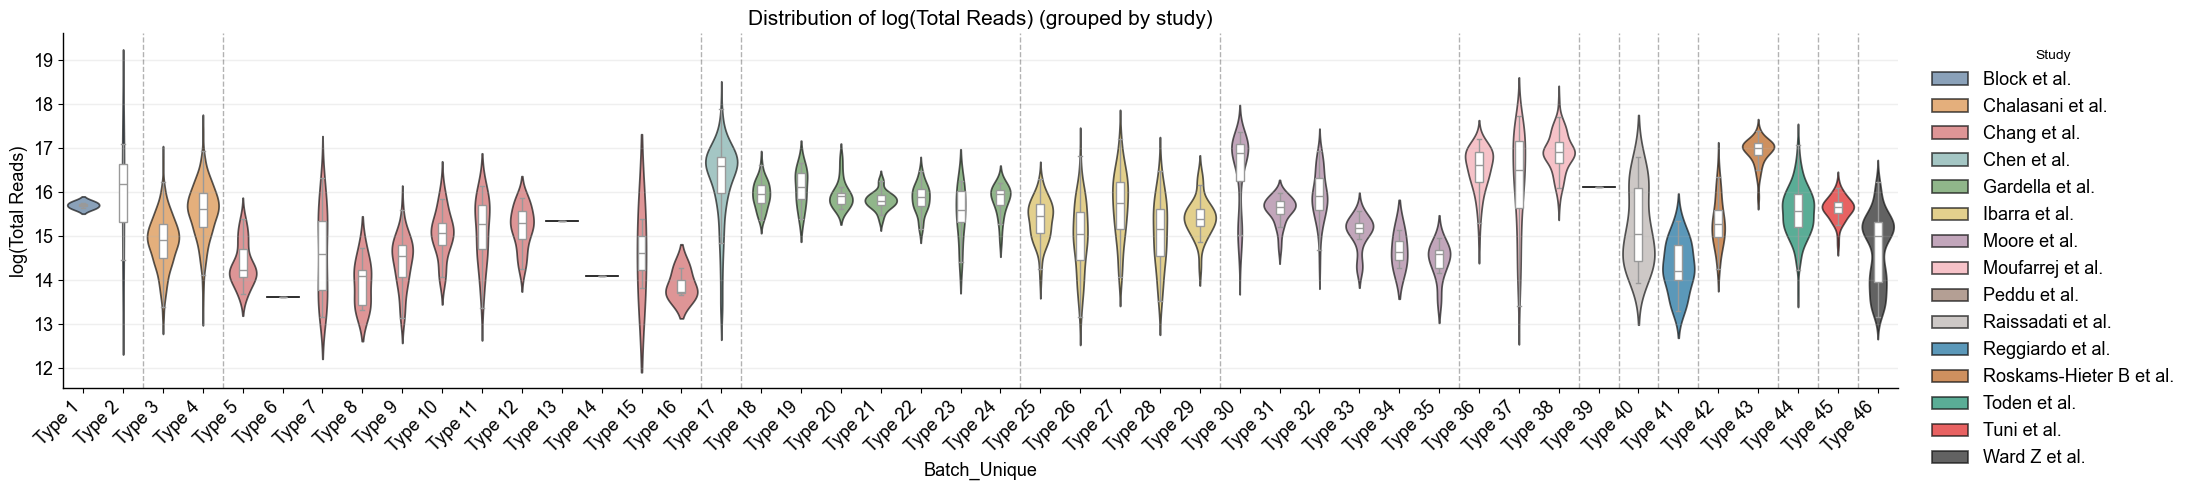

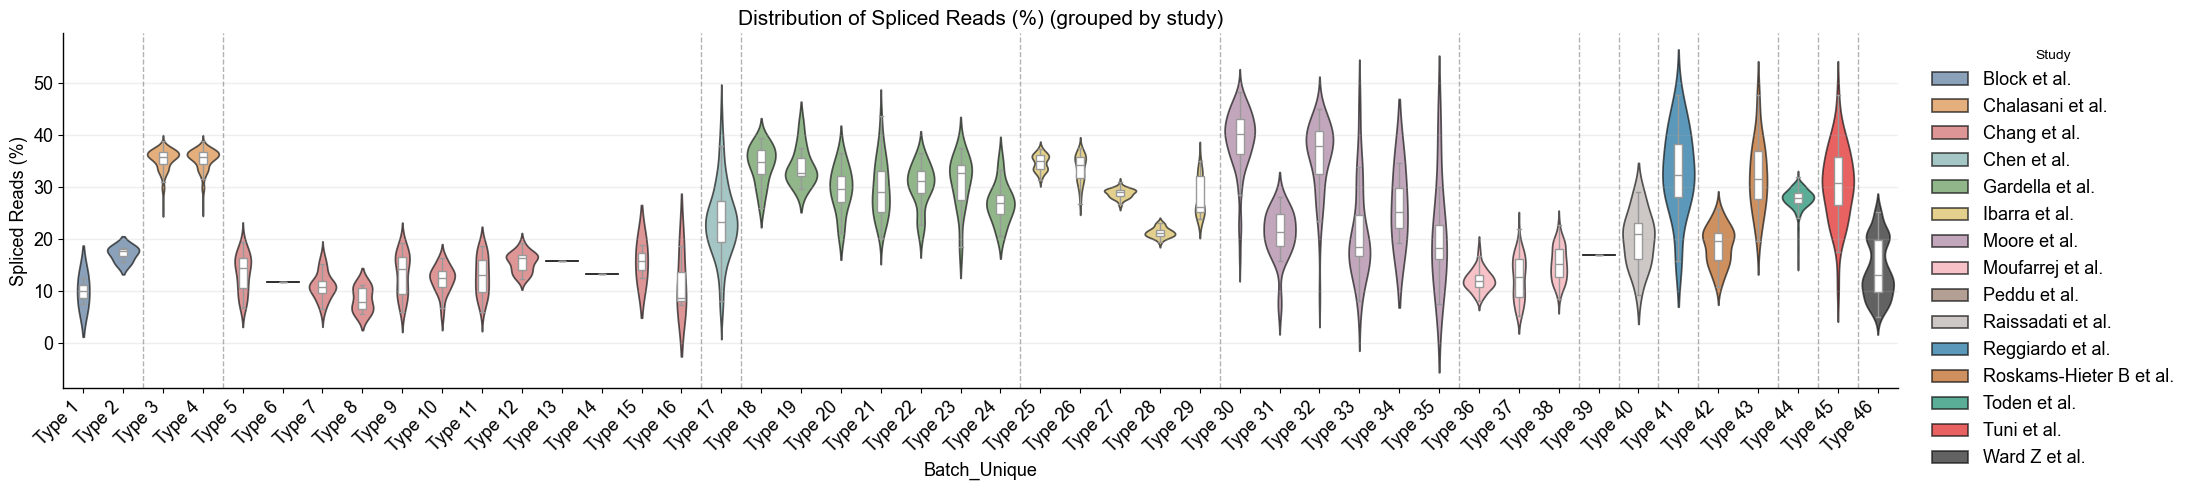

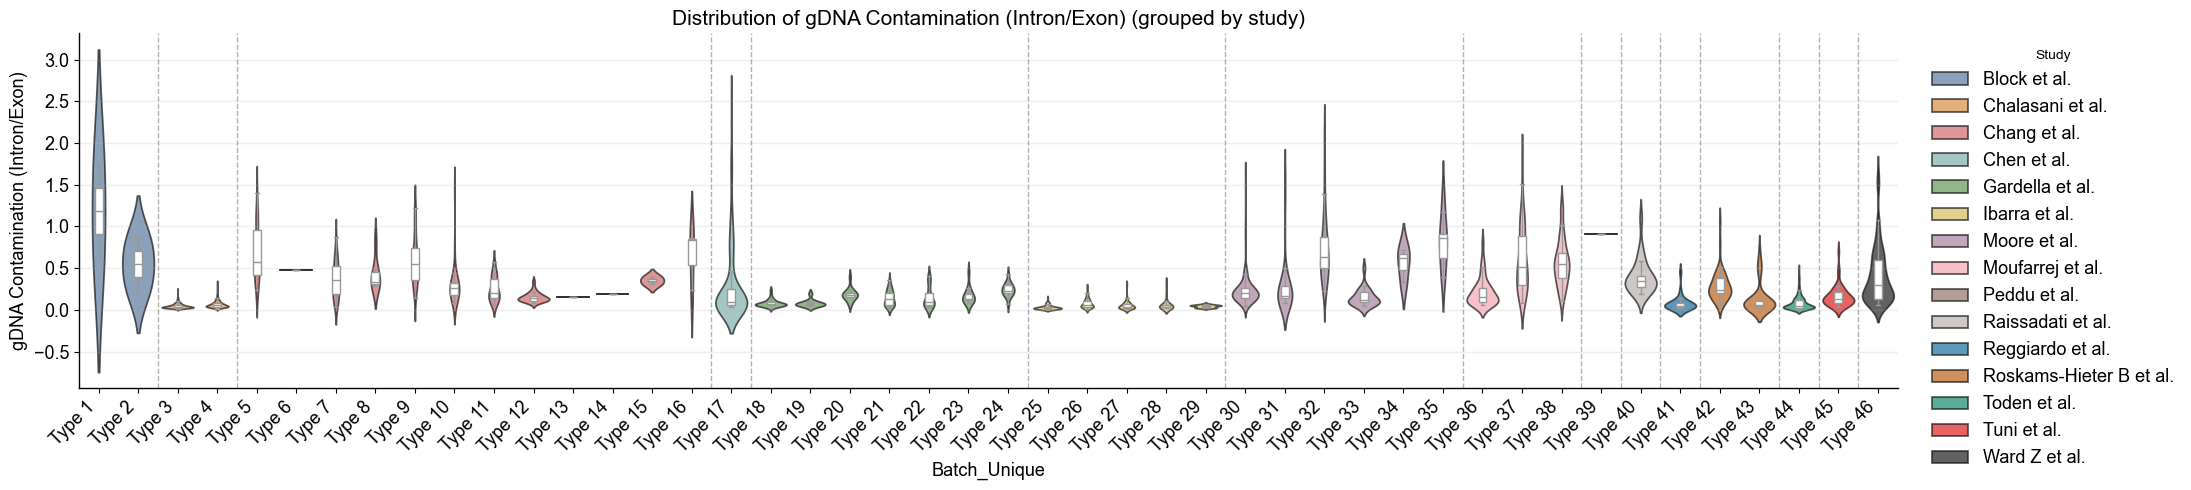

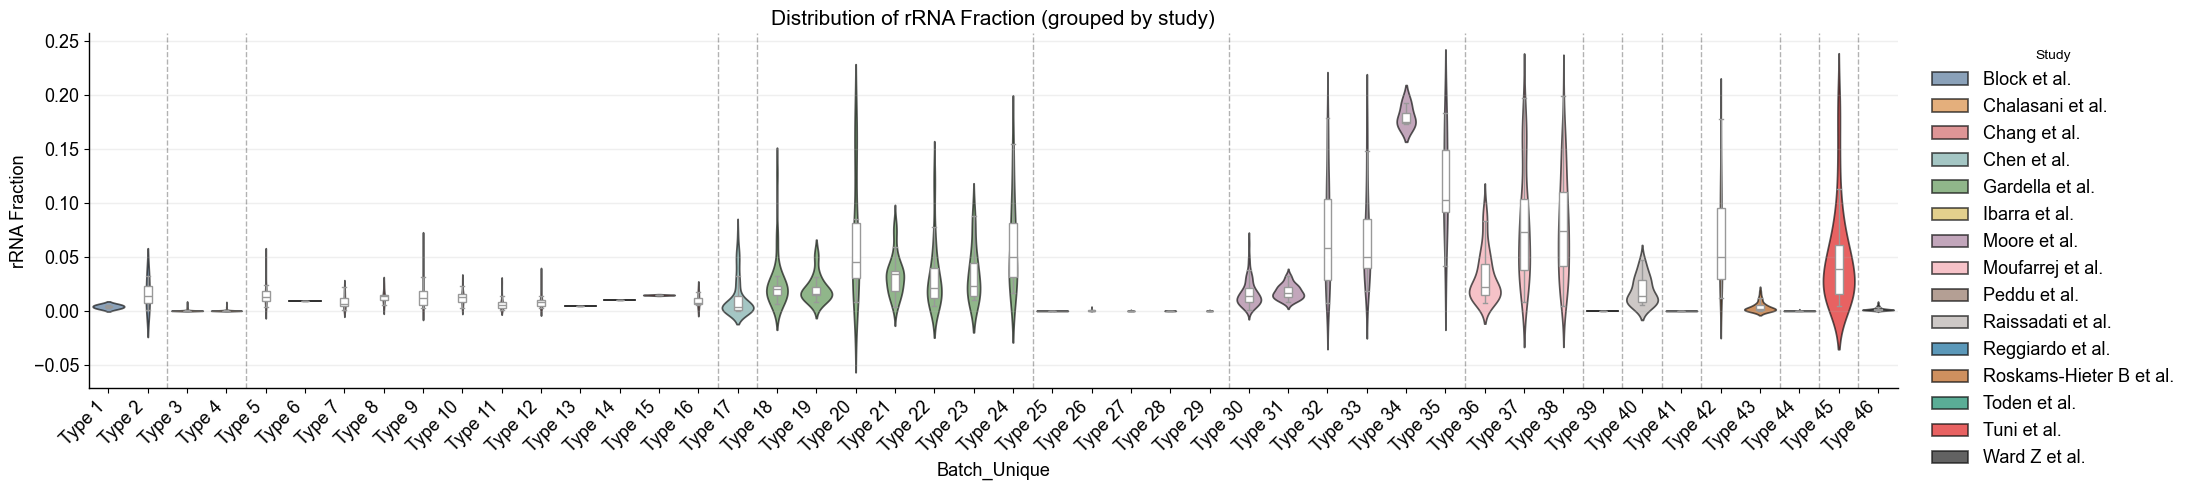

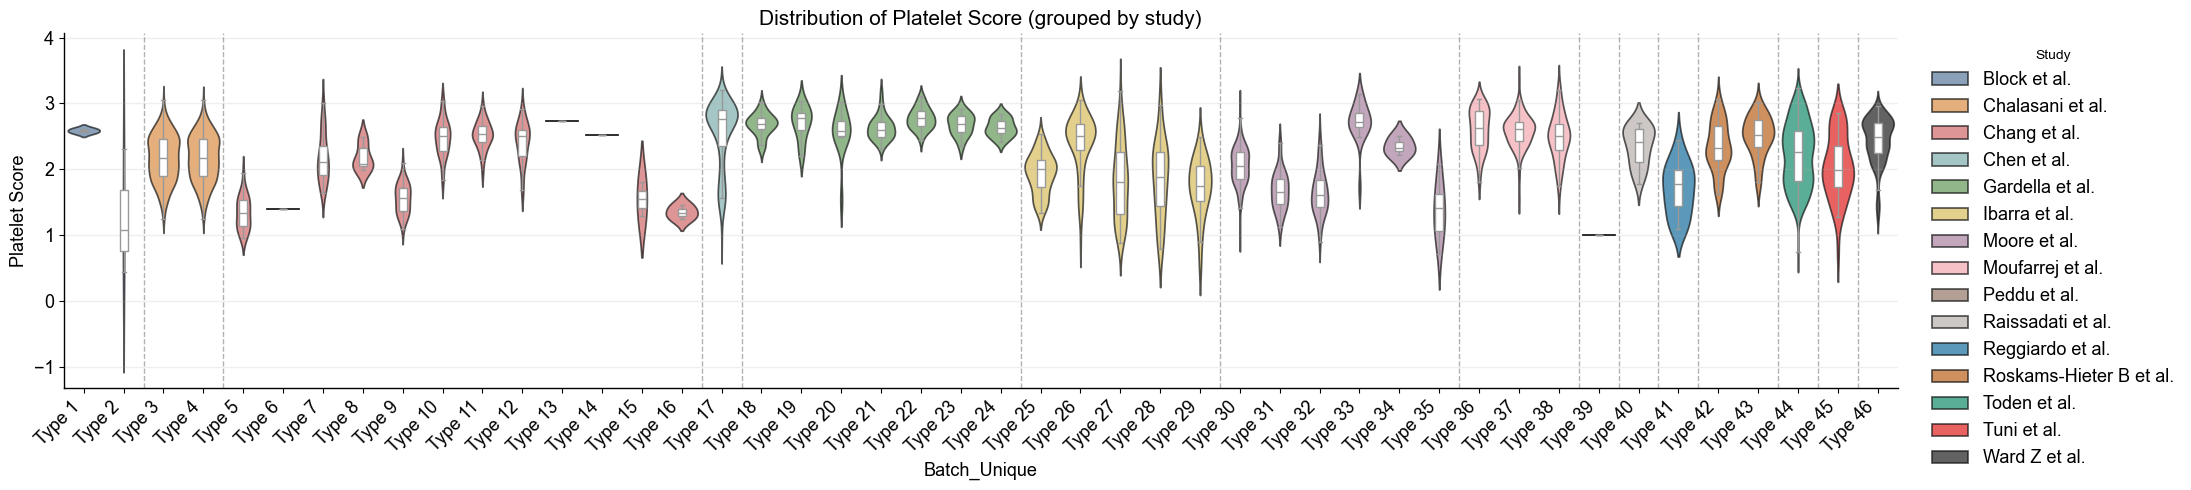

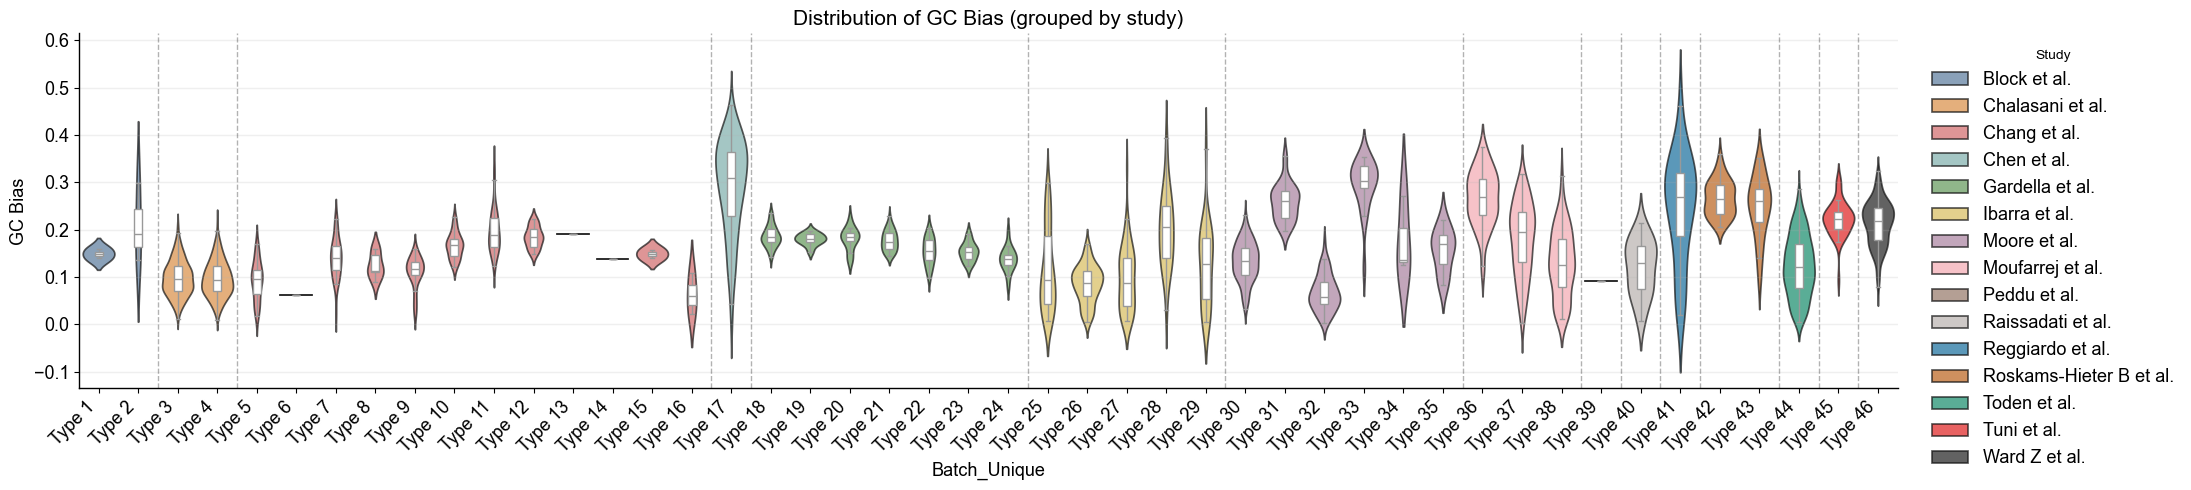

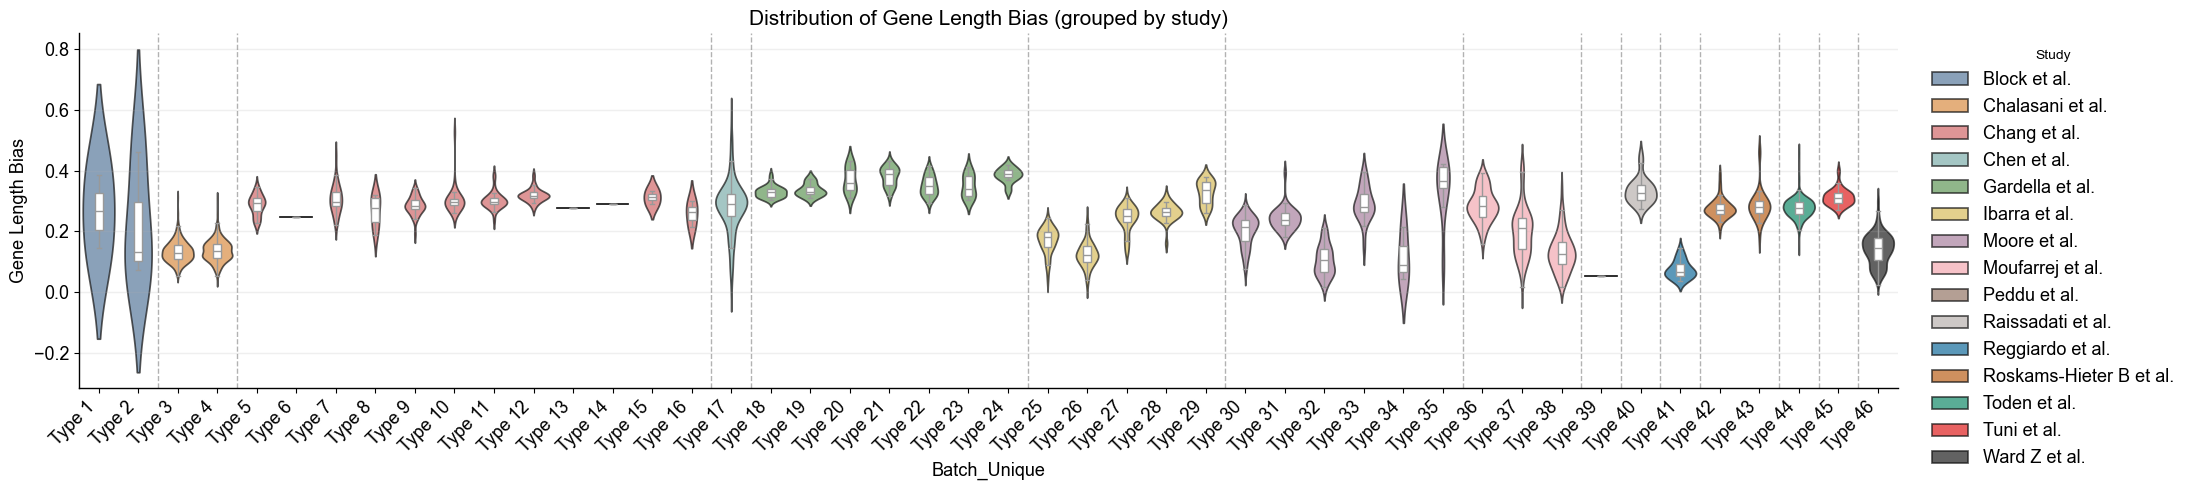

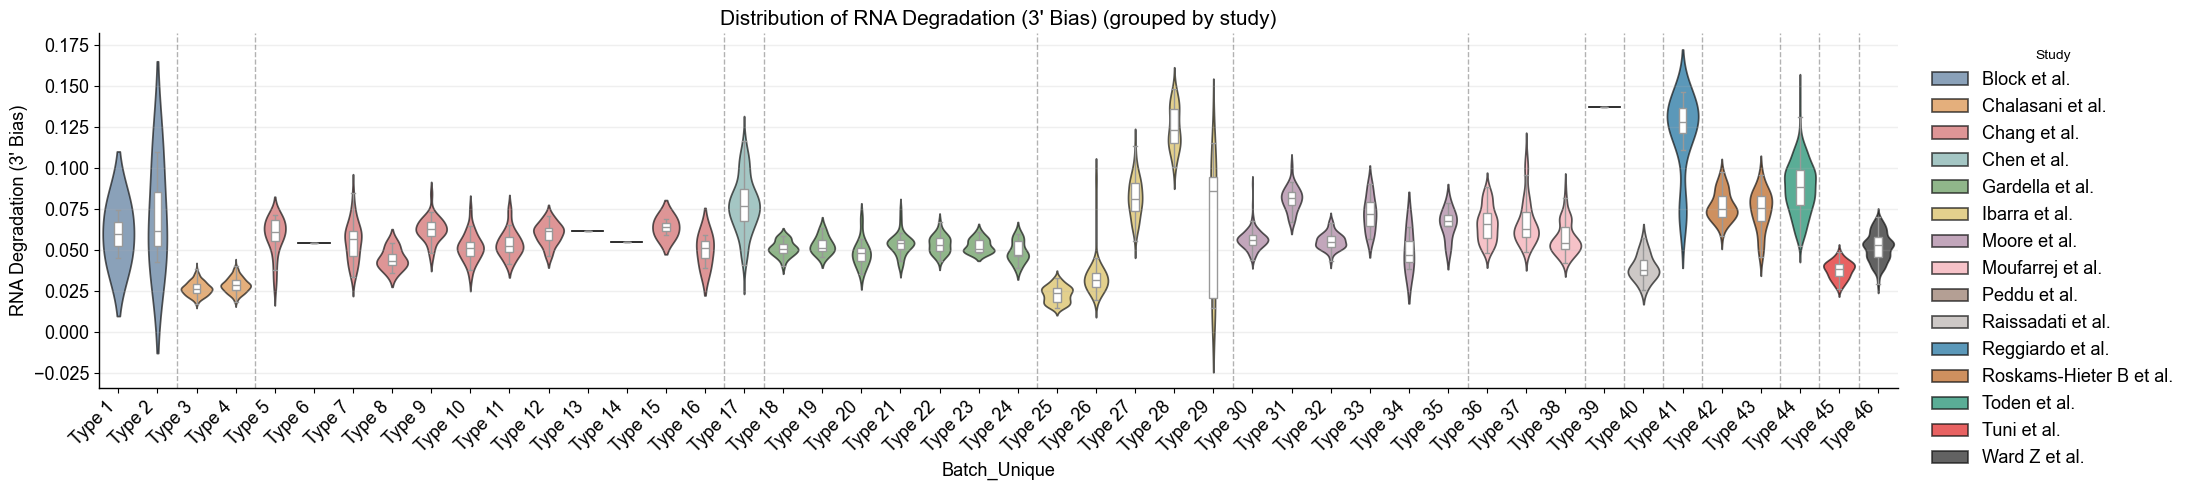

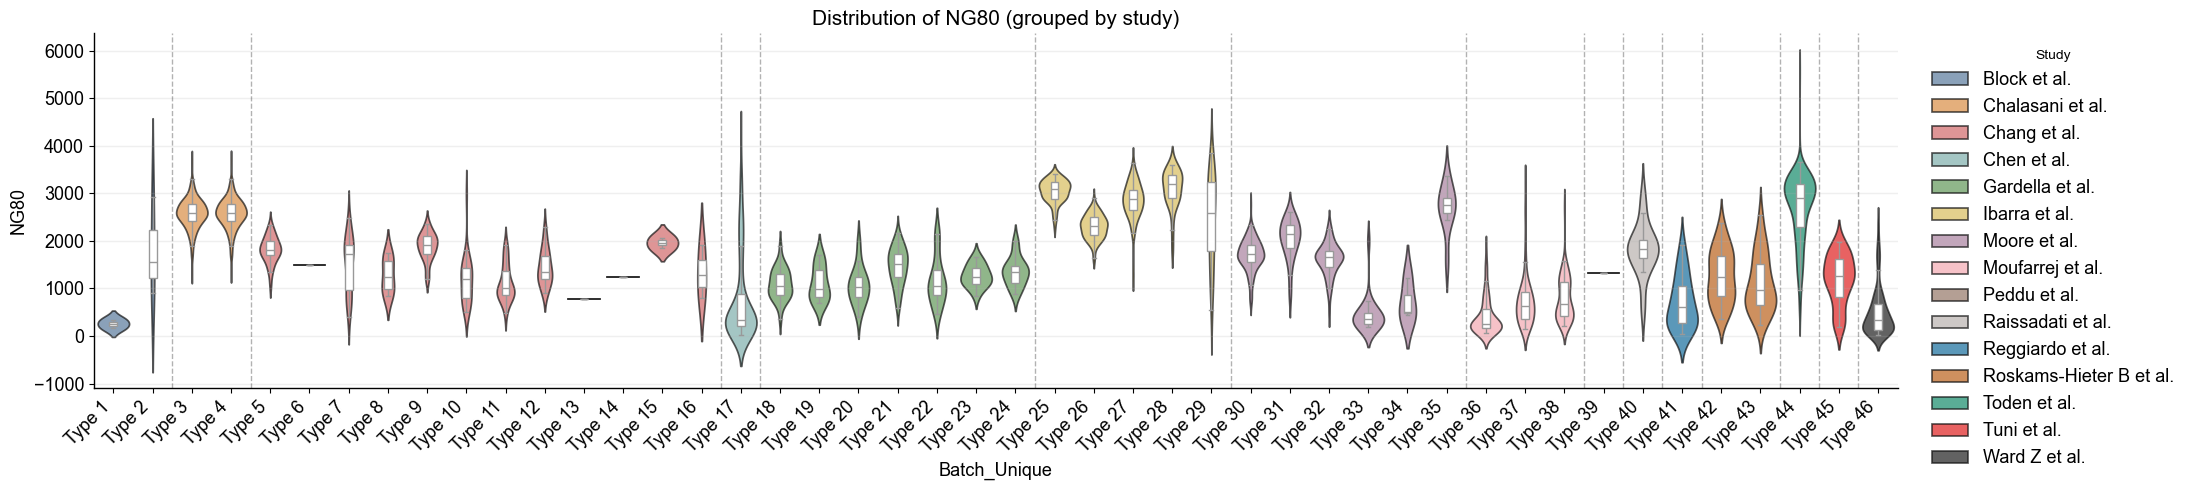

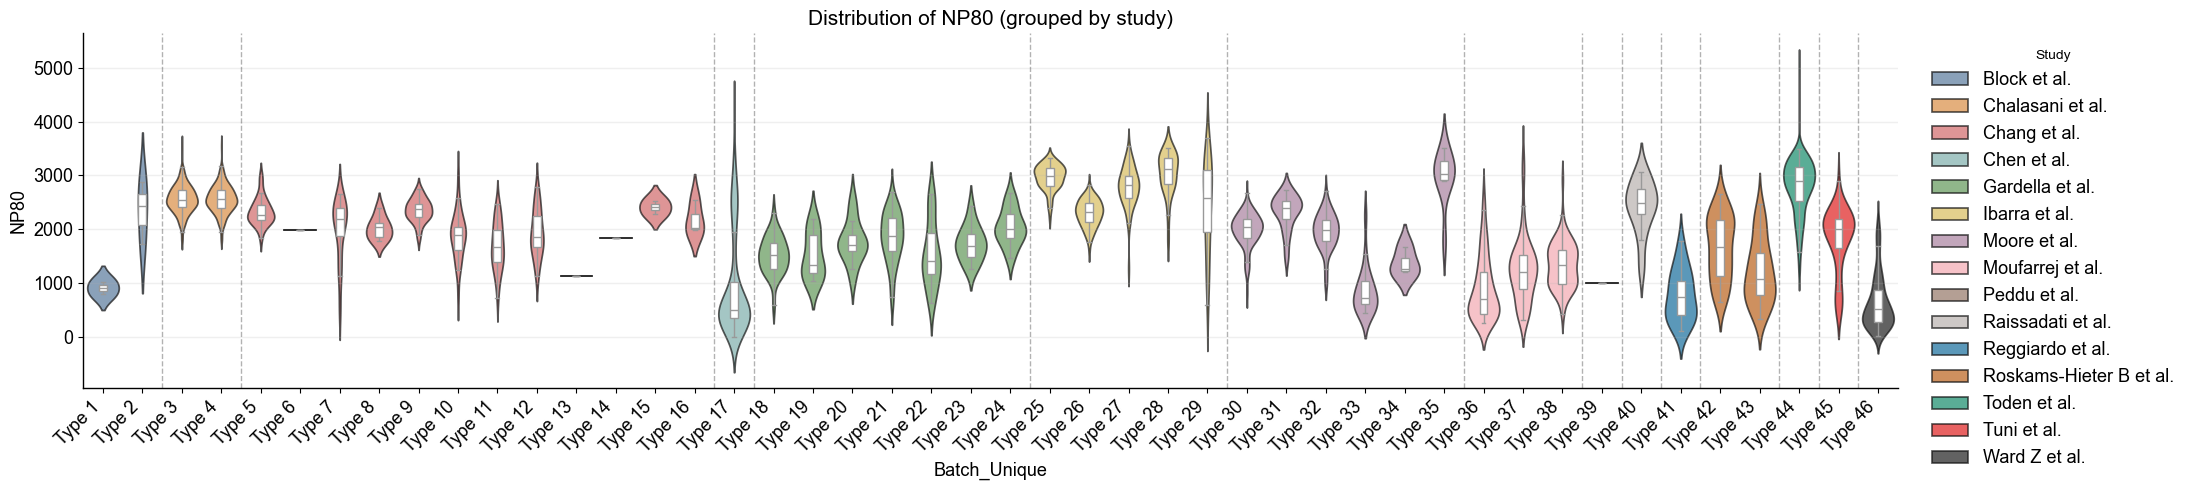

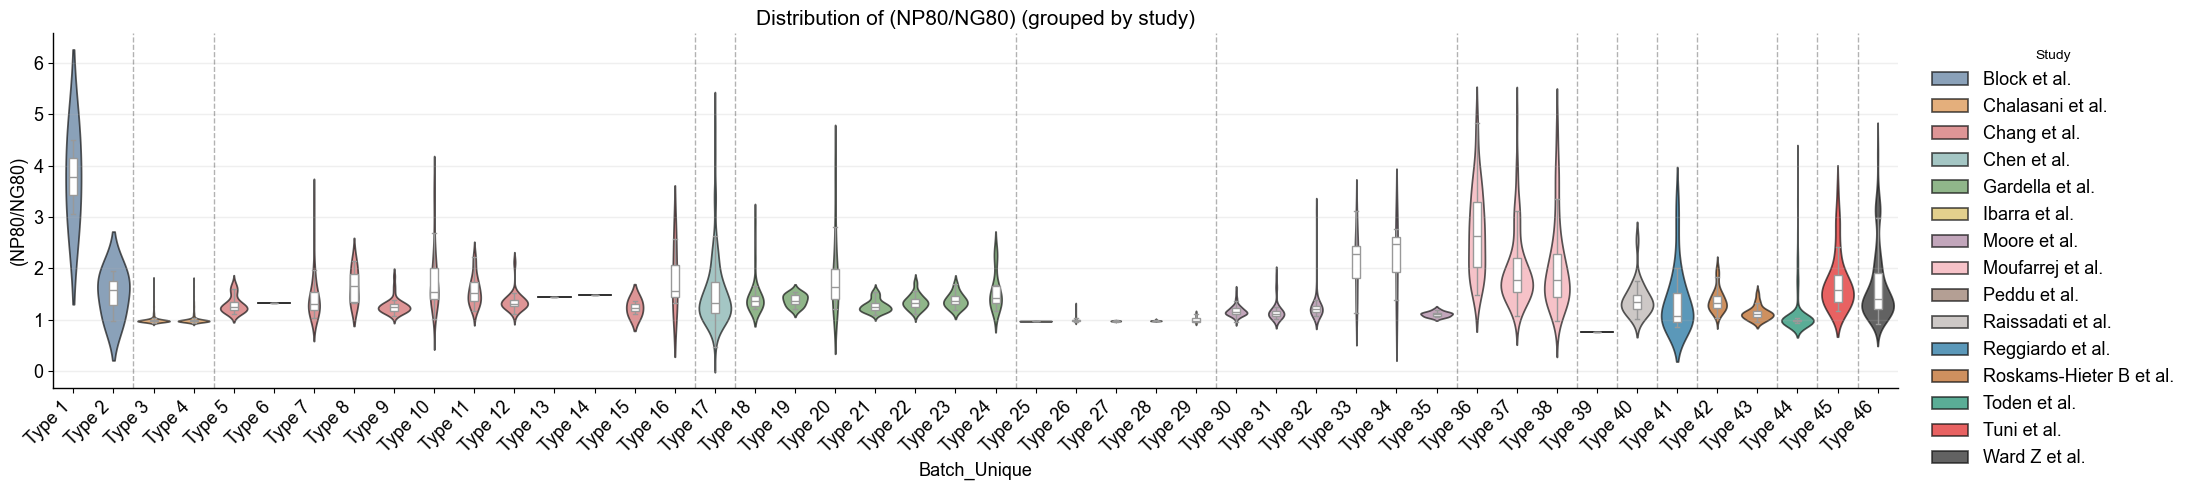


### Batch Effect Statistics ###
                              Metric     H-stat  p-value  Eta_Sq
7          RNA Degradation (3' Bias)  2708.4530      0.0  0.8421
3                      rRNA Fraction  2617.6697      0.0  0.8134
1                  Spliced Reads (%)  2561.6823      0.0  0.7957
8                               NG80  2395.0900      0.0  0.7430
6                   Gene Length Bias  2299.0090      0.0  0.7126
9                               NP80  2238.9360      0.0  0.6936
10                       (NP80/NG80)  2173.6910      0.0  0.6730
2   gDNA Contamination (Intron/Exon)  2017.0998      0.0  0.6235
5                            GC Bias  1750.9966      0.0  0.5394
0                   log(Total Reads)  1535.7813      0.0  0.4713
4                     Platelet Score  1096.7874      0.0  0.3325

[PERMANOVA] Pseudo-F: 118.2692, p=0.0010


In [4]:
from scipy.stats import zscore

df_obs = adata.obs.copy().sort_values(["Author", "Batch_ID"])
bias_metrics = EDA_BIAS_METRICS
ordered_batches = df_obs["Batch_ID"].unique()
df_obs["Batch_Unique"] = pd.Categorical(df_obs["Batch_ID"], categories=ordered_batches, ordered=True)

batch_info = df_obs.groupby("Batch_ID", sort=False, observed=True)["Author"].first()
author_change_indices = np.where(batch_info.values[:-1] != batch_info.values[1:])[0] + 0.5
batch_type_dict = {b: f"Type {i+1}" for i, b in enumerate(ordered_batches)}

plot_batch_metric_violins(
    df_obs, bias_metrics, batch_col="Batch_Unique", author_col="Author",
    author_change_indices=author_change_indices, batch_type_dict=batch_type_dict,
    save_path=EDA_BIAS_BATCH_DIR / "batch_metric_violins" / "dist"
)
df_kw, permanova_res = analyze_batch_statistics(df_obs, bias_metrics, "Batch_Unique")

In [5]:
df_kw.to_csv(EDA_BIAS_BATCH_DIR / "batch_metric_violins" / "kruskal_wallis_results.tsv", sep='\t')

In [6]:
permanova_res.to_csv(EDA_BIAS_BATCH_DIR / "batch_metric_violins" / "permanova_results.tsv", sep='\t')

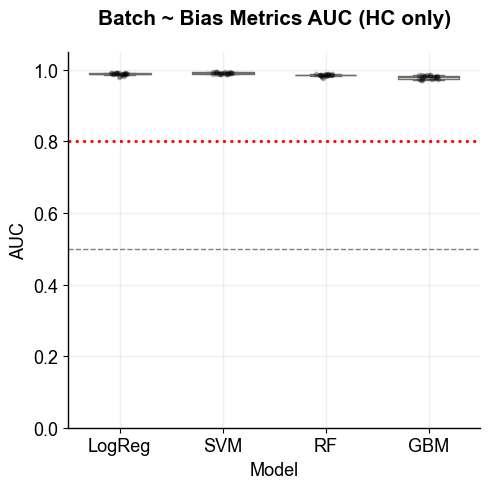

In [7]:
batch_pred_res = check_batch_classification_power(adata, bias_metrics, target_col="Author")

my_pal = {"LogReg": "#A8D8EA", "SVM": "#AA96DA", "RF": "#FCBAD3", "GBM": "#FFFFD2"}
plt.figure(figsize=(5, 5))
sns.boxplot(data=batch_pred_res, x="Model", y="AUC", hue="Model",
            palette=my_pal, showfliers=False, width=0.6, legend=False)
sns.stripplot(data=batch_pred_res, x="Model", y="AUC",
              color="black", alpha=0.3, jitter=True, size=4)
plt.axhline(0.5, color="gray", linestyle="--", label="Random Chance (0.5)")
plt.axhline(0.8, color="red", linestyle=":", linewidth=2)
plt.title("Batch ~ Bias Metrics AUC (HC only)", fontweight="bold", pad=20)
plt.ylabel("AUC")
plt.ylim(0, 1.05)
plt.grid(alpha=0.2)
plt.tight_layout()
EDA_BIAS_BATCH_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(EDA_BIAS_BATCH_DIR / "batch_classification_auc.png", bbox_inches='tight')
plt.show()

Running discrete covariate AUC evaluation (HC only, batch-disjoint splits) ...
  [Drop] instrument: classes confined to <2 batches or too few samples: ['Ilumina HiSeq X Ten', 'Illumina NextSeq 2000', 'Illumina HiSeq X Ten']
  instrument                                   : n_classes= 5  n= 799  n_batches=34  folds=20  mean_AUC=0.867
  [Drop] rna_extraction_kit_short_name: classes confined to <2 batches or too few samples: ['MOF', 'Promega', 'Qiagen ExoRNeasy']
  rna_extraction_kit_short_name                : n_classes= 3  n= 813  n_batches=34  folds=20  mean_AUC=0.960
  [Drop] plasma_tubes_short_name: classes confined to <2 batches or too few samples: ['Unknown']
  plasma_tubes_short_name                      : n_classes= 4  n= 834  n_batches=36  folds=20  mean_AUC=0.943
  [Drop] library_prep_kit_short_name: classes confined to <2 batches or too few samples: ['Swift 2S kit ', 'SMARTer Pico v1', 'SMART-Seq']
  library_prep_kit_short_name                  : n_classes= 3  n= 701  n_batches

,n_classes,n_samples,n_batches,n_folds,best_AUC,concern,μAUC_GBM,μAUC_LogReg,μAUC_RF,μAUC_SVM,σAUC_GBM,σAUC_LogReg,σAUC_RF,σAUC_SVM
Broad Protocol Category,2,863,35,20,1.000,High (>0.8),0.939,0.944,1.000,0.927,0.127,0.074,0.001,0.094
Library Prep Kit,3,701,34,20,0.998,High (>0.8),0.997,0.996,0.997,0.998,0.003,0.006,0.003,0.002
cDNA Library Type,2,996,37,20,0.995,High (>0.8),0.844,0.935,0.995,0.926,0.207,0.139,0.011,0.067
UMI,2,996,37,20,0.990,High (>0.8),0.965,0.978,0.987,0.990,0.032,0.019,0.016,0.016
Library Selection,2,996,37,20,0.984,High (>0.8),0.768,0.923,0.984,0.895,0.214,0.080,0.024,0.103
RNA Extraction Kit,3,813,34,20,0.983,High (>0.8),0.971,0.944,0.983,0.941,0.048,0.068,0.022,0.073
Plasma Tube Type,4,834,36,20,0.958,High (>0.8),0.929,0.935,0.949,0.958,0.052,0.071,0.035,0.045
DNase Treatment,5,946,36,20,0.925,High (>0.8),0.897,0.903,0.925,0.880,0.056,0.041,0.023,0.029
Sequencer Model,5,799,34,20,0.897,High (>0.8),0.877,0.827,0.865,0.897,0.056,0.059,0.055,0.041
Centrifuge Protocol,3,996,37,20,0.644,Low,0.604,0.644,0.608,0.611,0.164,0.153,0.135,0.121


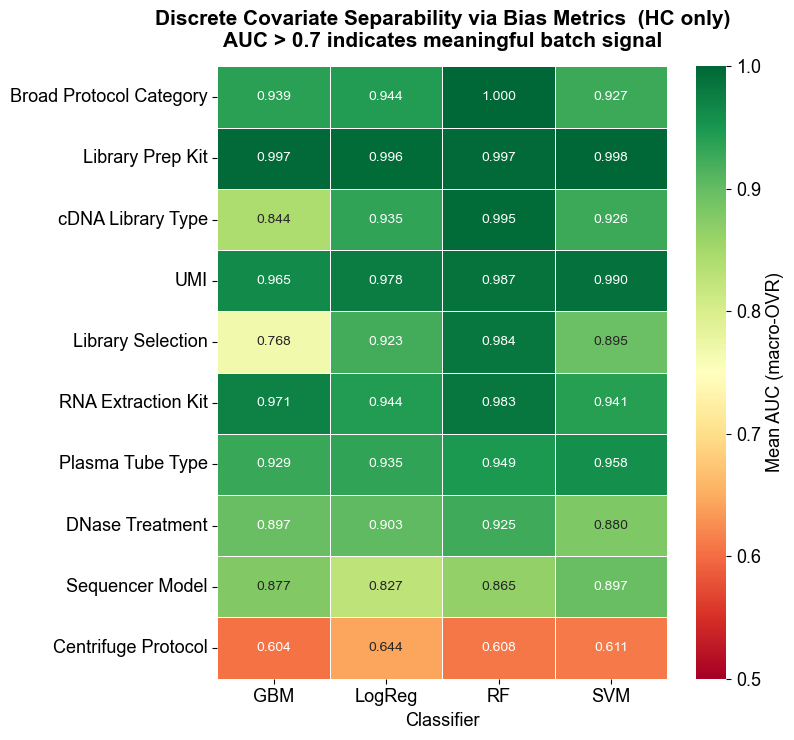

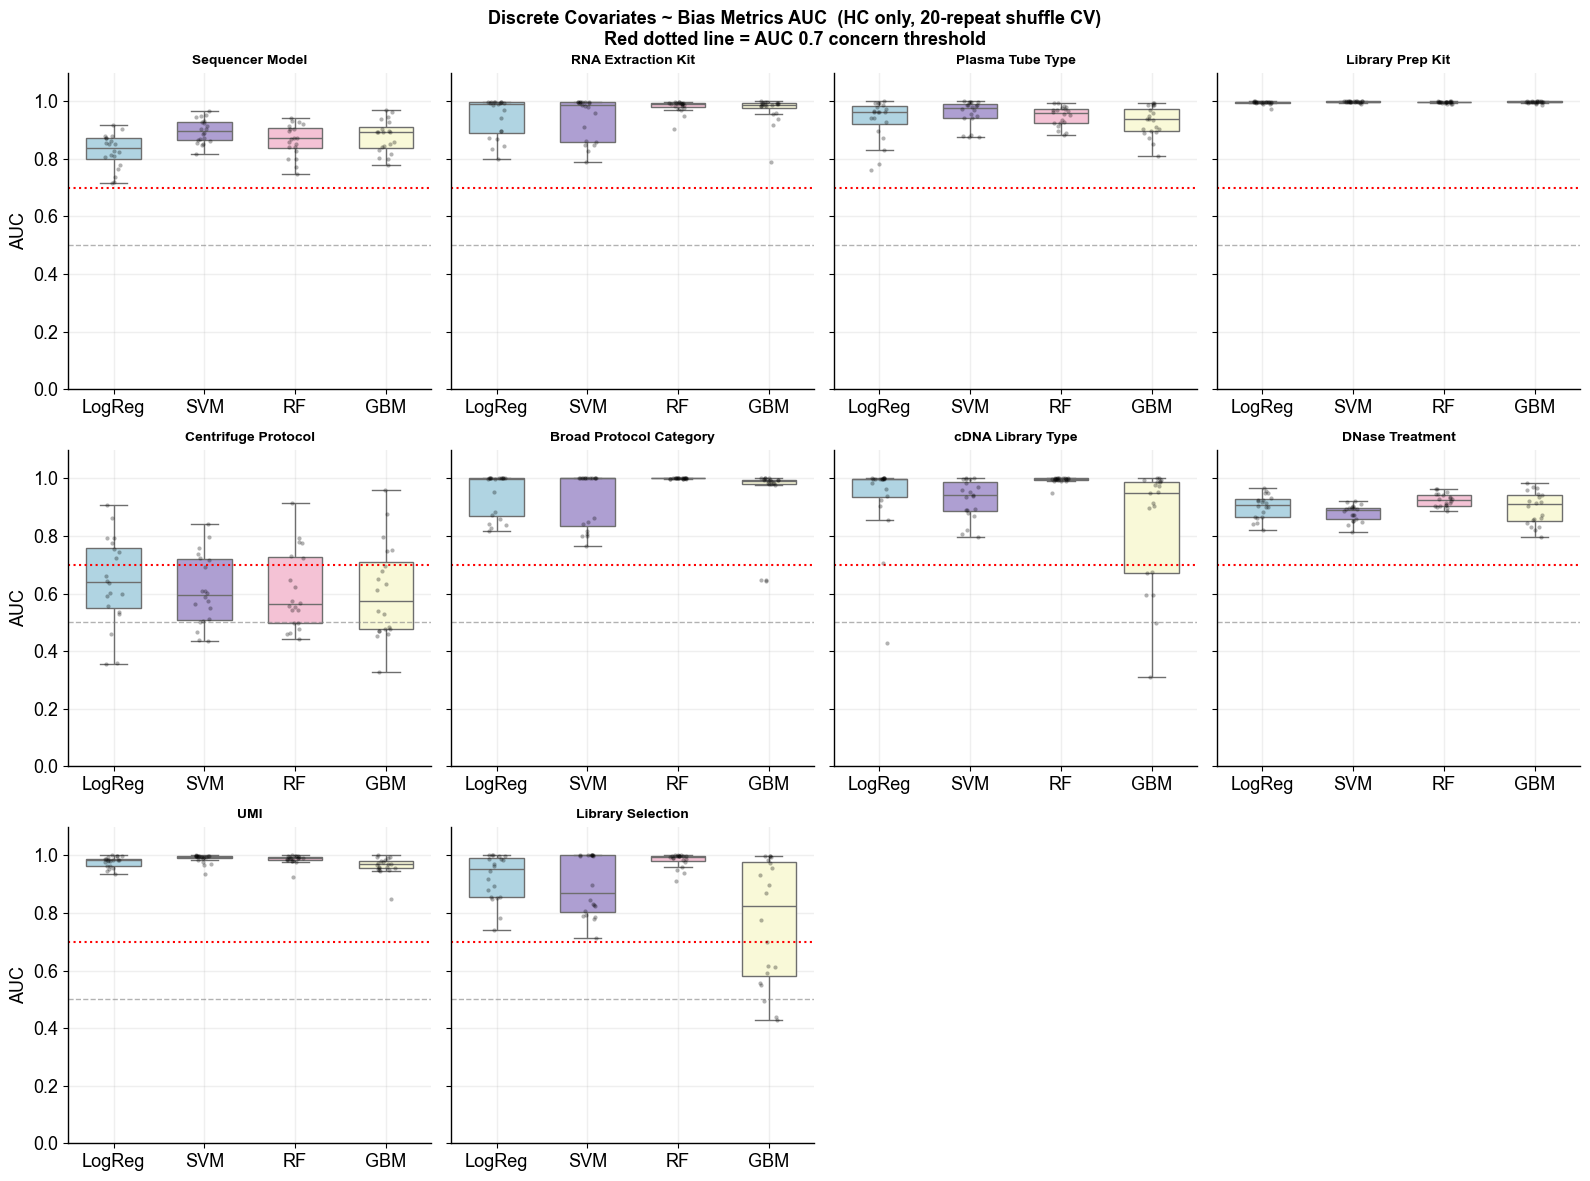

Saved -> /project/cfRNA_NormativeModeling/EDA/Analysis_Results/BiasBatch/discrete_covariate_auc


In [8]:
AUC_DIR = EDA_BIAS_BATCH_DIR / "discrete_covariate_auc"
AUC_DIR.mkdir(parents=True, exist_ok=True)
DISCRETE_COVARIATES = [
    "instrument",                    
    "rna_extraction_kit_short_name", 
    "plasma_tubes_short_name",       
    "library_prep_kit_short_name",   
    "Centrifuge_Protocol",           
    "broad_protocol_category",       
    "cdna_library_type",            
    "dnase",                         
    "UMI",                           
    "librarylayout",                
    "library_selection",             
]

BIAS_FOR_CLF = [
    "log(Total Reads)", "Spliced Reads (%)", "gDNA Contamination (Intron/Exon)",
    "rRNA Fraction", "RNA Degradation (3' Bias)", "Platelet Score",
    "GC Bias", "Gene Length Bias", "NG80", "(NP80/NG80)",
]

print("Running discrete covariate AUC evaluation (HC only, batch-disjoint splits) ...")
df_covar_auc, df_covar_meta = check_discrete_covariate_batch_effects(
    adata,
    bias_list           = BIAS_FOR_CLF,
    covariates          = DISCRETE_COVARIATES,
    hc_label            = "Healthy Control",
    phenotype_col       = "Phenotype_Processed",
    min_class_samples   = 10,
    n_repeats           = 20,
    group_col           = "Batch_ID",
    min_batches_per_class = 2,
)
print(f"\nTotal AUC records: {len(df_covar_auc):,}")

label_map = {
    "Batch_ID":                      "Batch ID (Granular)",
    "instrument":                    "Sequencer Model",
    "rna_extraction_kit_short_name": "RNA Extraction Kit",
    "plasma_tubes_short_name":       "Plasma Tube Type",
    "library_prep_kit_short_name":   "Library Prep Kit",
    "Centrifuge_Protocol":           "Centrifuge Protocol",
    "broad_protocol_category":       "Broad Protocol Category",
    "cdna_library_type":             "cDNA Library Type",
    "dnase":                         "DNase Treatment",
    "UMI":                           "UMI",
    "librarylayout":                 "Library Layout",
    "library_selection":             "Library Selection",
}

auc_pivot = (
    df_covar_auc.groupby(["Covariate", "Model"])["AUC"]
    .agg(mean="mean", std="std")
    .round(3)
    .unstack("Model")
)
auc_pivot.columns = [f"{stat}_{mdl}" for stat, mdl in auc_pivot.columns]
auc_pivot.index   = [label_map.get(c, c) for c in auc_pivot.index]

if not df_covar_meta.empty:
    meta_idx = df_covar_meta.set_index("covariate")
    meta_idx.index = [label_map.get(c, c) for c in meta_idx.index]
    auc_pivot = auc_pivot.join(meta_idx[["n_classes", "n_samples", "n_batches", "n_folds"]], how="left")

mean_cols  = [c for c in auc_pivot.columns if c.startswith("mean_")]
best_auc   = auc_pivot[mean_cols].max(axis=1)
auc_pivot["best_AUC"] = best_auc.round(3)
auc_pivot["concern"]  = best_auc.apply(
    lambda x: "High (>0.8)" if x > 0.8 else ("Moderate (>0.7)" if x > 0.7 else "Low")
)

display_cols = (
    ["n_classes", "n_samples", "n_batches", "n_folds", "best_AUC", "concern"]
    + [c for c in mean_cols]
    + [c for c in auc_pivot.columns if c.startswith("std_")]
)
display_cols = [c for c in display_cols if c in auc_pivot.columns]

print("Discrete Covariate Batch Effect Summary")
display(
    auc_pivot[display_cols]
    .sort_values("best_AUC", ascending=False)
    .rename(columns=lambda c: c.replace("mean_", "μAUC_").replace("std_", "σAUC_"))
)

plot_covariate_auc_heatmap(
    df_covar_auc,
    save_path = AUC_DIR / "auc_heatmap.png",
)

plot_covariate_auc_violins(
    df_covar_auc,
    n_cols    = 4,
    save_path = AUC_DIR / "auc_violins.png",
)

auc_pivot.to_csv(AUC_DIR / "summary.csv")
df_covar_auc.to_csv(AUC_DIR / "auc_raw.csv", index=False)
print(f"Saved -> {AUC_DIR}")